# Field Mapping 04 - Spatial Correlation Analysis

**Report Date:** March 2025  
**Dataset:** Oregon Willamette Valley Agricultural Fields (50 fields)

## Executive Summary

This notebook analyzes spatial correlations between satellite metrics, soil properties, and terrain data for 4 randomly selected fields from the 50-field dataset.

### Key Findings Summary Table

| Section | Finding | Metric |
|---------|---------|--------|
| **7.1 Satellite-Soil** | Correlation between satellite indices and soil properties | r values |
| **7.2 Satellite-Terrain** | Correlation between satellite indices and terrain properties | r values |
| **7.3 Key Findings** | Summary of significant correlations | p < 0.05 |

## Section 1: Setup & Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy import stats
import json
import os
import random

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Configuration Parameters
MIN_PIXEL_COUNT = 30  # Minimum pixels required for valid correlation
SATELLITE_METRICS = ['ndvi', 'msavi', 'evi', 'ndmi']
SOIL_PROPERTIES = ['ph', 'om_pct', 'clay_pct', 'sand_pct', 'cec']  # No drainage
TERRAIN_PROPERTIES = ['elevation', 'slope', 'aspect']

# Define absolute paths - notebook runs from /notebooks/ so go up one level
PROJECT_ROOT = '/workspaces/ag-skills-demo'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data/assignment-03')
TERRAIN_DIR = os.path.join(PROJECT_ROOT, 'data/assignment-04/terrain')
SOIL_DIR = os.path.join(PROJECT_ROOT, 'data/assignment-04/soil')
SATELLITE_DIR = os.path.join(PROJECT_ROOT, 'data/assignment-03/satellite')
TERRAIN_RESAMPLED_DIR = os.path.join(PROJECT_ROOT, 'data/assignment-04/terrain_resampled')
DOCS_DIR = os.path.join(PROJECT_ROOT, 'docs/assignment-03')

os.makedirs(TERRAIN_RESAMPLED_DIR, exist_ok=True)

print('Configuration loaded:')
print(f'  MIN_PIXEL_COUNT: {MIN_PIXEL_COUNT}')
print(f'  SATELLITE_METRICS: {SATELLITE_METRICS}')
print(f'  SOIL_PROPERTIES: {SOIL_PROPERTIES}')
print(f'  TERRAIN_PROPERTIES: {TERRAIN_PROPERTIES}')



Configuration loaded:
  MIN_PIXEL_COUNT: 30
  SATELLITE_METRICS: ['ndvi', 'msavi', 'evi', 'ndmi']
  SOIL_PROPERTIES: ['ph', 'om_pct', 'clay_pct', 'sand_pct', 'cec']
  TERRAIN_PROPERTIES: ['elevation', 'slope', 'aspect']


## Section 2: Helper Functions

In [32]:
def calculate_pixel_correlation(array1, array2, min_pixels=MIN_PIXEL_COUNT, nodata_value=-9999):
    """Calculate Pearson correlation between two arrays, handling NoData."""
    valid_mask = ~np.isnan(array1) & ~np.isnan(array2)
    if nodata_value is not None:
        valid_mask = valid_mask & (array1 != nodata_value) & (array2 != nodata_value)
    valid_count = np.sum(valid_mask)
    if valid_count < min_pixels:
        return np.nan, np.nan, valid_count
    x = array1[valid_mask]
    y = array2[valid_mask]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, valid_count
    r, p = stats.pearsonr(x, y)
    return r, p, valid_count


def calculate_polygon_correlation(soil_tiff_path, sat_tiff_path, labels_json_path, property_column):
    """Calculate correlation between satellite and soil at polygon level."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    with rasterio.open(soil_tiff_path) as src:
        soil_data = src.read(1)
    with rasterio.open(sat_tiff_path) as src:
        sat_data = src.read(1)
    min_h = min(sat_data.shape[0], soil_data.shape[0])
    min_w = min(sat_data.shape[1], soil_data.shape[1])
    sat_crop = sat_data[:min_h, :min_w]
    soil_crop = soil_data[:min_h, :min_w]
    polygon_means = []
    polygon_values = []
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    for label_id in label_to_mukey.keys():
        label_int = int(label_id)
        soil_def = soil_defs.get(label_id, {})
        property_value = soil_def.get(property_column)
        if property_value is None:
            continue
        polygon_mask = (soil_crop == label_int)
        if np.sum(polygon_mask) == 0:
            continue
        sat_mean = np.nanmean(sat_crop[polygon_mask])
        polygon_means.append(sat_mean)
        polygon_values.append(float(property_value))
    if len(polygon_means) < 3:
        return np.nan, np.nan, len(polygon_means)
    r, p = stats.pearsonr(polygon_means, polygon_values)
    return r, p, len(polygon_means)


def get_polygon_stats(soil_tiff_path, sat_tiff_path, labels_json_path, property_column):
    """Get per-polygon statistics for display."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    with rasterio.open(soil_tiff_path) as src:
        soil_data = src.read(1)
    with rasterio.open(sat_tiff_path) as src:
        sat_data = src.read(1)
    min_h = min(sat_data.shape[0], soil_data.shape[0])
    min_w = min(sat_data.shape[1], soil_data.shape[1])
    sat_crop = sat_data[:min_h, :min_w]
    soil_crop = soil_data[:min_h, :min_w]
    results = []
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    for label_id in label_to_mukey.keys():
        label_int = int(label_id)
        soil_def = soil_defs.get(label_id, {})
        property_value = soil_def.get(property_column)
        if property_value is None:
            continue
        polygon_mask = (soil_crop == label_int)
        if np.sum(polygon_mask) == 0:
            continue
        sat_mean = np.nanmean(sat_crop[polygon_mask])
        sat_std = np.nanstd(sat_crop[polygon_mask])
        results.append({
            'polygon': label_id,
            'soil_type': soil_def.get('muname', 'Unknown'),
            'property_value': float(property_value),
            'sat_mean': sat_mean,
            'sat_std': sat_std,
            'n_pixels': np.sum(polygon_mask)
        })
    return results


def load_tiff(tiff_path):
    """Load TIFF file and return data array and valid pixel mask."""
    with rasterio.open(tiff_path) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        valid_mask = ~np.isnan(data)
        if nodata is not None and not np.isnan(nodata):
            valid_mask = valid_mask & (data != nodata)
    return data, valid_mask, nodata


def load_tiff_with_nodata(tiff_path):
    """Load TIFF file and return data with nan substituted for nodata."""
    with rasterio.open(tiff_path) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        plot_data = np.where(data == nodata, np.nan, data)
    return plot_data, None, nodata


def resample_to_match(source_path, reference_path, output_path=None):
    """Resample source raster to match reference raster resolution."""
    with rasterio.open(reference_path) as ref:
        ref_crs = ref.crs
        ref_width = ref.width
        ref_height = ref.height
    with rasterio.open(source_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, ref_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({'crs': ref_crs, 'transform': transform, 'width': width, 'height': height})
        if output_path:
            with rasterio.open(output_path, 'w', **kwargs) as dst:
                for i in range(1, src.count + 1):
                    data = src.read(i)
                    result = np.zeros((height, width), dtype=data.dtype)
                    reproject(source=data, destination=result,
                              src_transform=src.transform, src_crs=src.crs,
                              dst_transform=transform, dst_crs=ref_crs,
                              resampling=Resampling.bilinear)
                    dst.write(result, i)
            return output_path
        else:
            result = np.zeros((height, width), dtype=src.dtypes[0])
            reproject(source=src.read(1), destination=result,
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=transform, dst_crs=ref_crs,
                      resampling=Resampling.bilinear)
            return result


def load_soil_with_properties(soil_tiff_path, labels_json_path, property_column):
    """Convert soil mukey integers to property values using labels JSON."""
    with open(labels_json_path) as f:
        labels = json.load(f)
    label_to_mukey = labels.get('label_to_mukey', {})
    soil_defs = labels.get('soil_definitions', {})
    label_to_value = {}
    for label_id, mukey_str in label_to_mukey.items():
        soil_def = soil_defs.get(label_id, {})
        value = soil_def.get(property_column)
        if value:
            label_to_value[int(label_id)] = float(value)
    with rasterio.open(soil_tiff_path) as src:
        data = src.read(1)
    output = np.full_like(data, np.nan, dtype=np.float64)
    for label_id, value in label_to_value.items():
        output[data == label_id] = value
    return output


def get_or_resample_terrain(field_id, terrain_prop, satellite_metric='ndvi'):
    """Get terrain data, resampling to match satellite resolution if needed."""
    terr_path = f'{TERRAIN_DIR}/{field_id}_{terrain_prop}.tif'
    sat_path = f'{SATELLITE_DIR}/{field_id}_{satellite_metric}.tif'
    resampled_path = f'{TERRAIN_RESAMPLED_DIR}/{field_id}_{terrain_prop}_{satellite_metric}.tif'
    if os.path.exists(resampled_path):
        return load_tiff_with_nodata(resampled_path)
    if os.path.exists(terr_path) and os.path.exists(sat_path):
        resample_to_match(terr_path, sat_path, resampled_path)
        return load_tiff_with_nodata(resampled_path)
    return None, None, None


SOIL_PROPERTY_DISPLAY = {'ph': 'pH', 'om_pct': 'Organic Matter (%)', 'clay_pct': 'Clay (%)', 
                         'sand_pct': 'Sand (%)', 'cec': 'CEC (meq/100g)'}
SATELLITE_DISPLAY = {'ndvi': 'NDVI', 'msavi': 'MSAVI', 'evi': 'EVI', 'ndmi': 'NDMI'}
TERRAIN_DISPLAY = {'elevation': 'Elevation (m)', 'slope': 'Slope (deg)', 'aspect': 'Aspect (deg)'}

print('Helper functions loaded.')

def plot_correlation_scatter(x_data, y_data, x_label, y_label, field_id, correlation_r, correlation_p, figsize=(6, 5)):
    """Create scatter plot with regression line and correlation stats."""
    fig, ax = plt.subplots(figsize=figsize)
    valid_mask = ~np.isnan(x_data) & ~np.isnan(y_data)
    x_valid = x_data[valid_mask]
    y_valid = y_data[valid_mask]
    if len(x_valid) == 0:
        ax.text(0.5, 0.5, 'No valid data for correlation', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{field_id}: {x_label} vs {y_label}')
        plt.tight_layout()
        return fig
    ax.scatter(x_valid, y_valid, alpha=0.4, s=15, c='steelblue', edgecolors='none')
    if not np.isnan(correlation_r) and np.std(x_valid) > 0 and np.std(y_valid) > 0:
        z = np.polyfit(x_valid, y_valid, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
        ax.plot(x_line, p(x_line), 'r-', lw=2, label=f'r = {correlation_r:.3f}')
        sig_star = '***' if correlation_p < 0.001 else ('**' if correlation_p < 0.01 else ('*' if correlation_p < 0.05 else ''))
        ax.text(0.05, 0.95, f'p = {correlation_p:.2e} {sig_star}', transform=ax.transAxes, fontsize=10, va='top')
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f'{field_id}: {x_label} vs {y_label}', fontsize=11, fontweight='bold')
    if not np.isnan(correlation_r):
        ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


Helper functions loaded: calculate_pixel_correlation, calculate_polygon_correlation, get_polygon_stats, load_tiff, load_tiff_with_nodata, resample_to_match, load_soil_with_properties, get_or_resample_terrain, get_field_boundary_coords, plot_correlation_scatter


## Section 3: Data Loading

In [33]:
# Load field boundaries
gdf = gpd.read_file(f'{DATA_DIR}/fields_complete.geojson')
print(f'Loaded {len(gdf)} fields')

# Load slope/aspect statistics
slope_df = pd.read_csv(f'{DATA_DIR}/field_slope_aspect.csv')
print(f'Loaded slope/aspect data for {len(slope_df)} fields')

Loaded 50 fields
Loaded slope/aspect data for 50 fields


## Section 4: Field Selection

In [34]:
# Select 4 random fields
selected_fields = random.sample(list(gdf['field_id']), 4)
print(f'Selected fields (seed={RANDOM_SEED}): {selected_fields}')

# Display field info
field_info = gdf[gdf['field_id'].isin(selected_fields)][['field_id', 'area_acres', 'cdl_crop', 'lat', 'lon']]
print('\nField Information:')
print(field_info.to_string(index=False))

Selected fields (seed=42): ['WV_AG_041', 'WV_AG_008', 'WV_AG_002', 'WV_AG_048']

Field Information:
 field_id  area_acres     cdl_crop       lat         lon
WV_AG_002   66.794644 Winter Wheat 44.188688 -123.183989
WV_AG_008   13.584710 Winter Wheat 44.592012 -122.698694
WV_AG_041   10.785175 Winter Wheat 44.450616 -123.102804
WV_AG_048   15.112003 Winter Wheat 44.184532 -123.171003


## Section 5: Per-Field Data Showcase

For each selected field, we display CDL crop type, soil maps, terrain maps, and satellite maps.

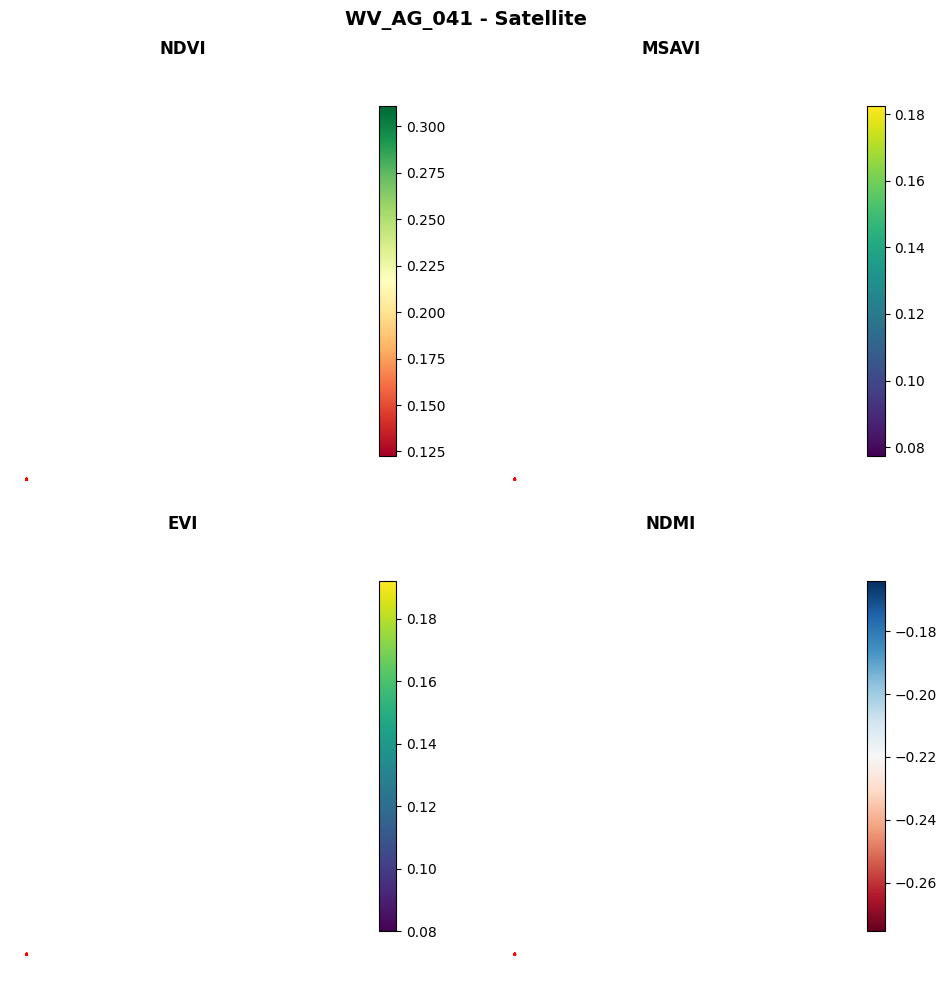

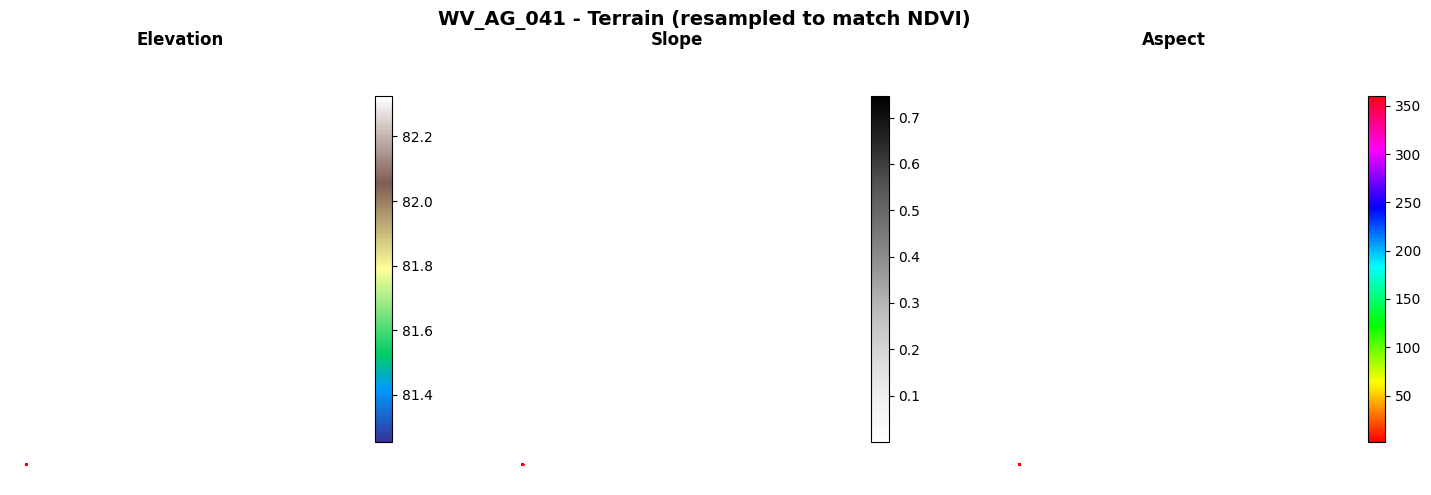

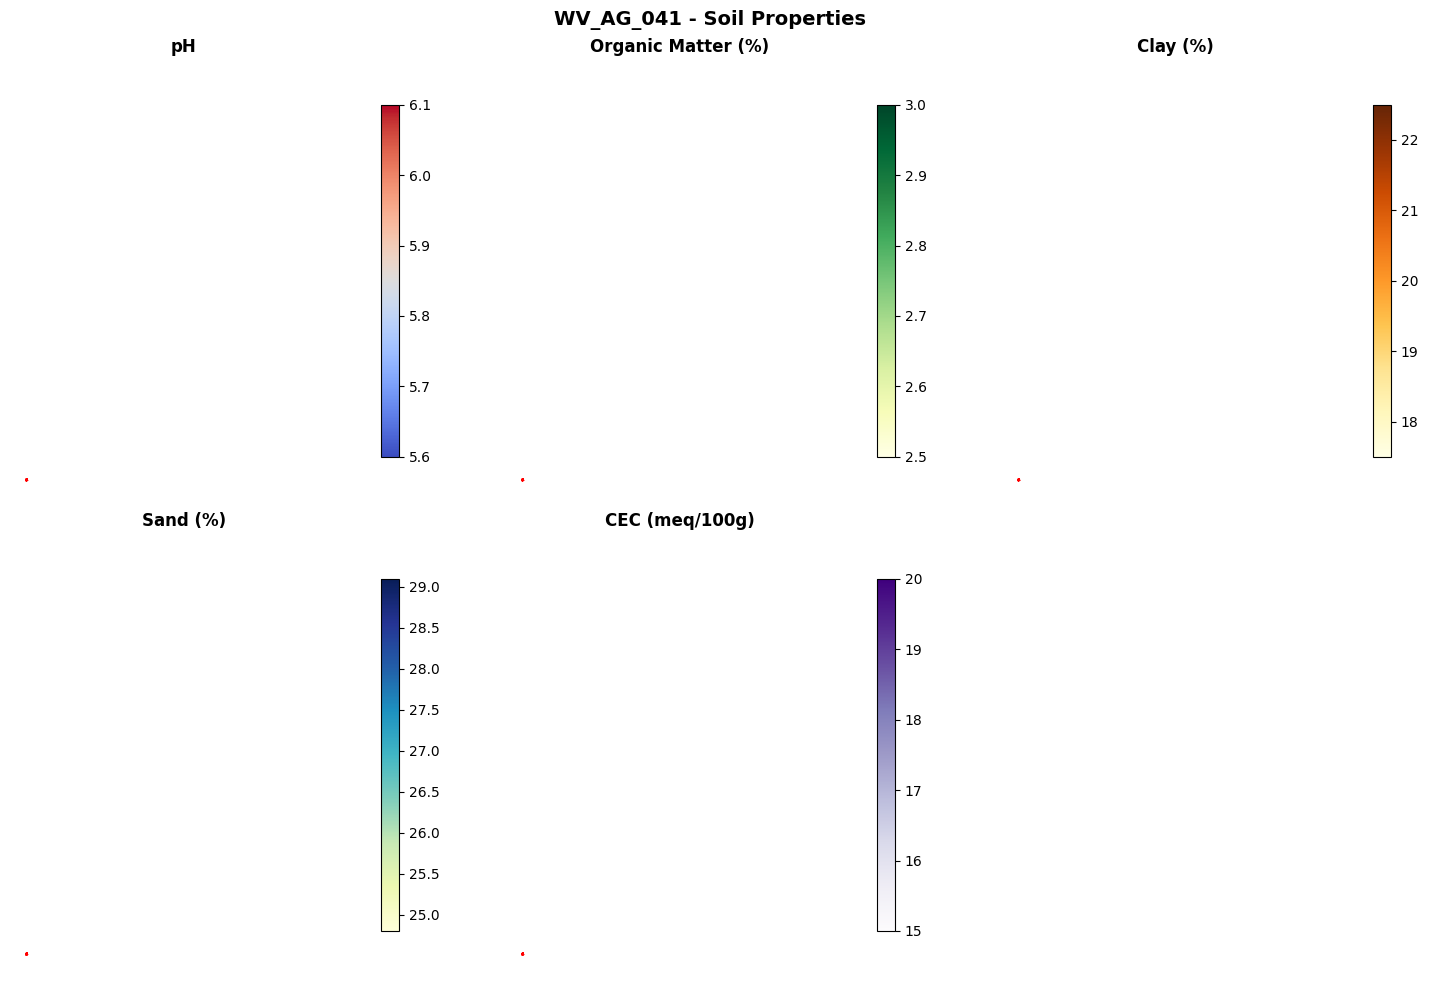

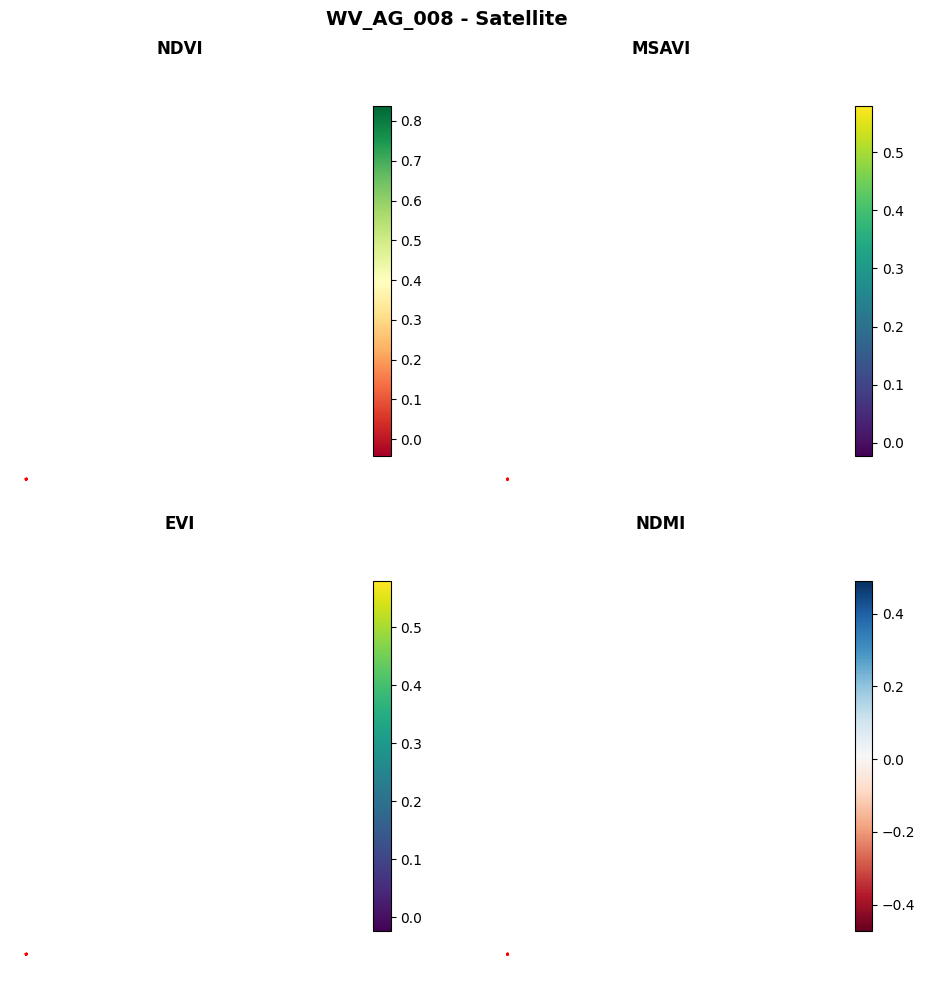

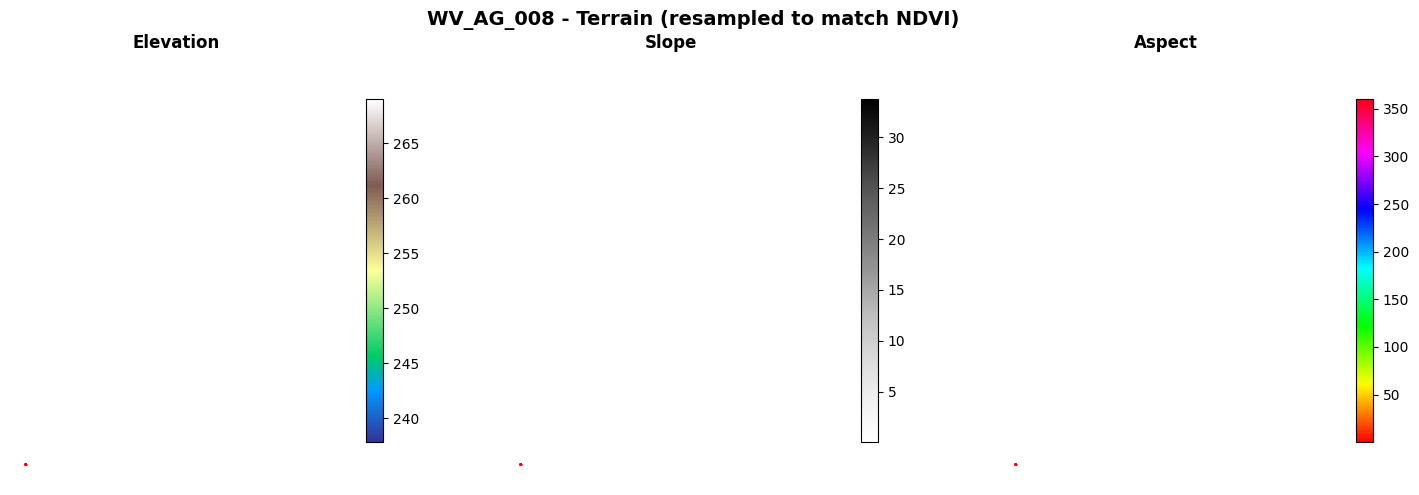

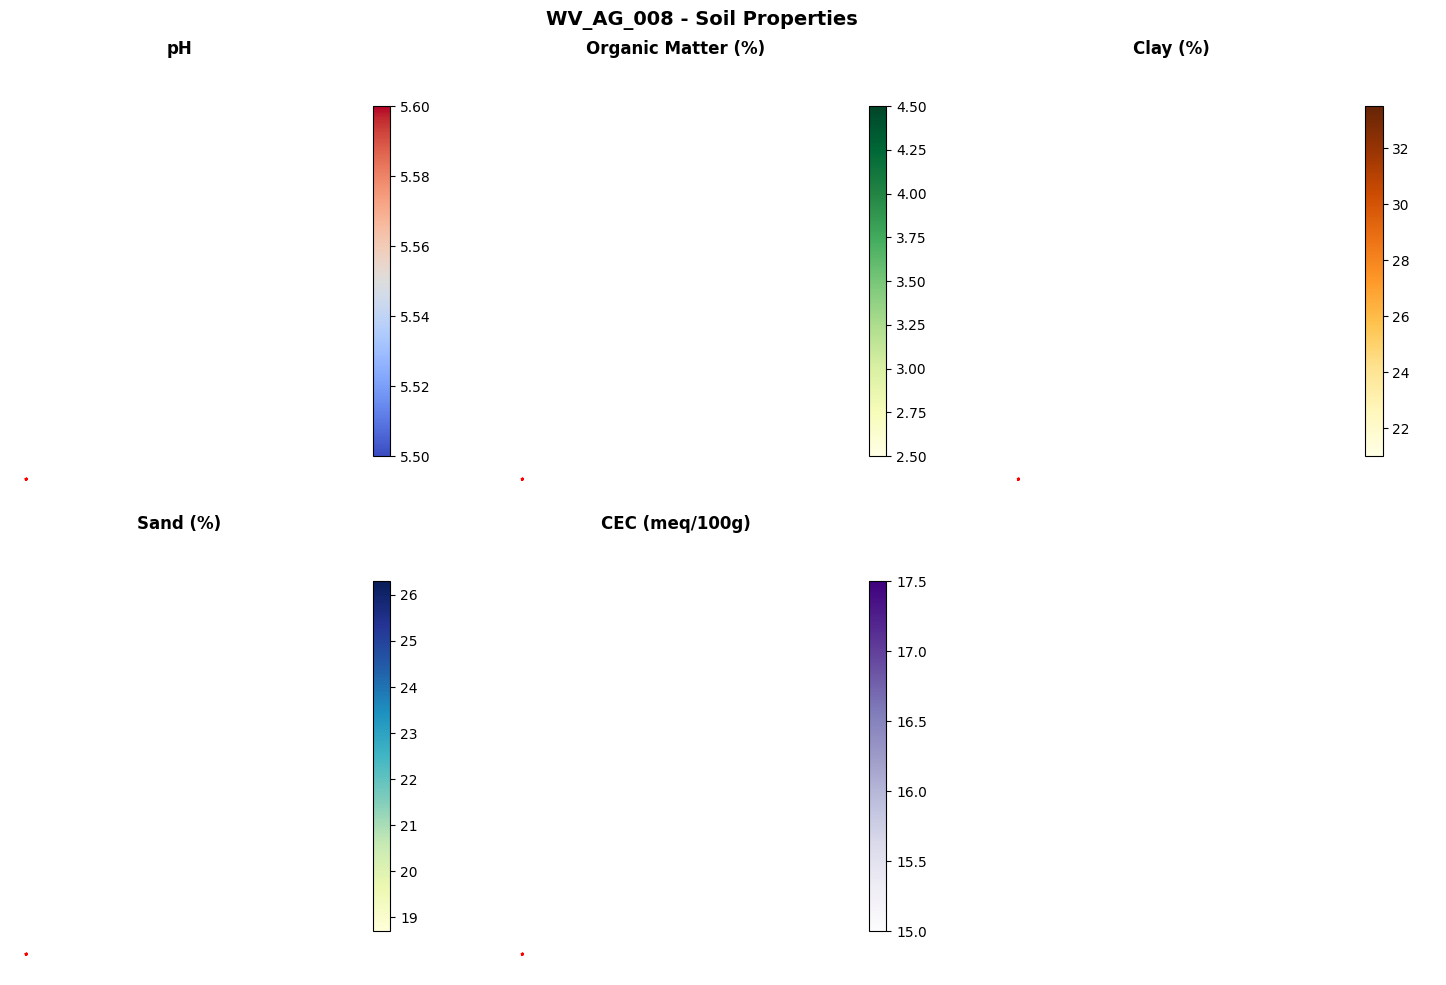

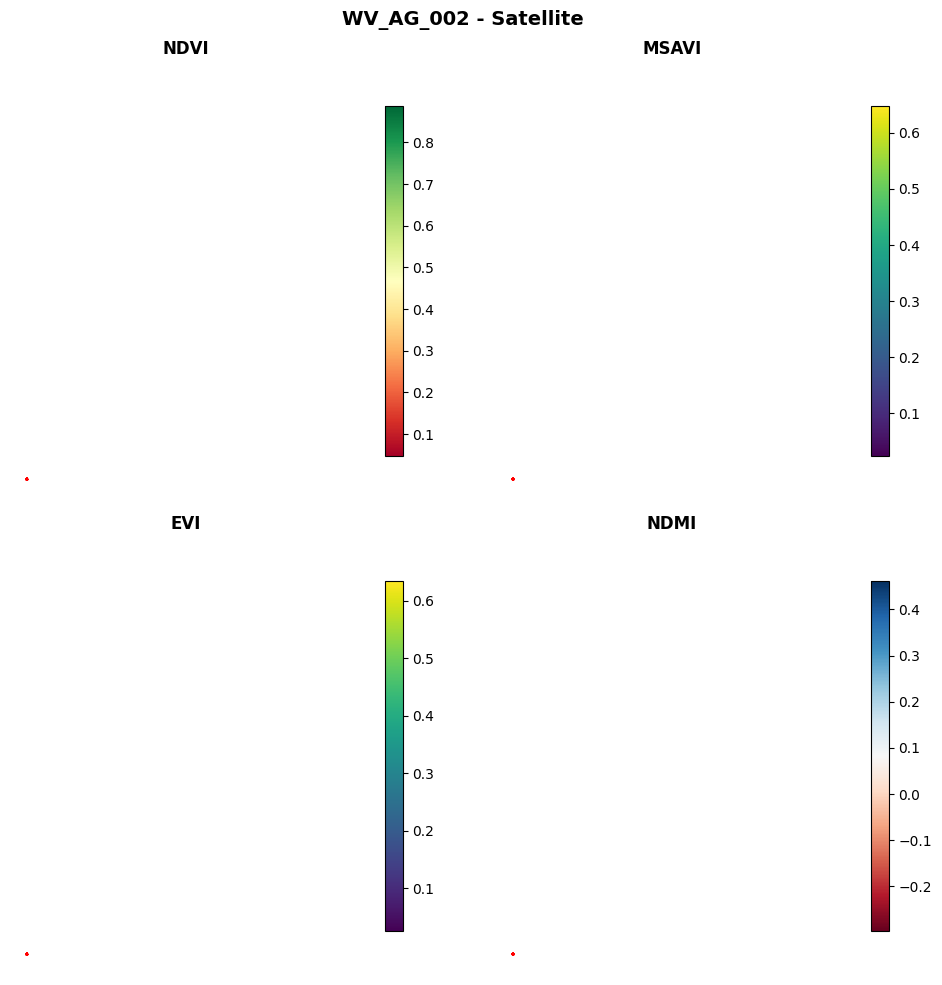

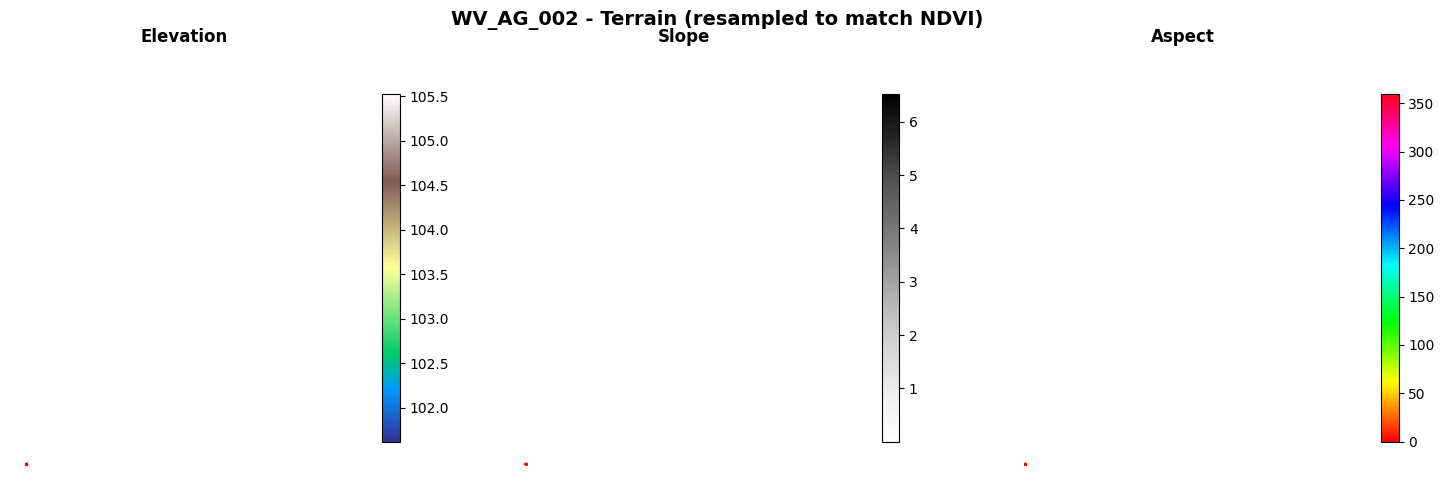

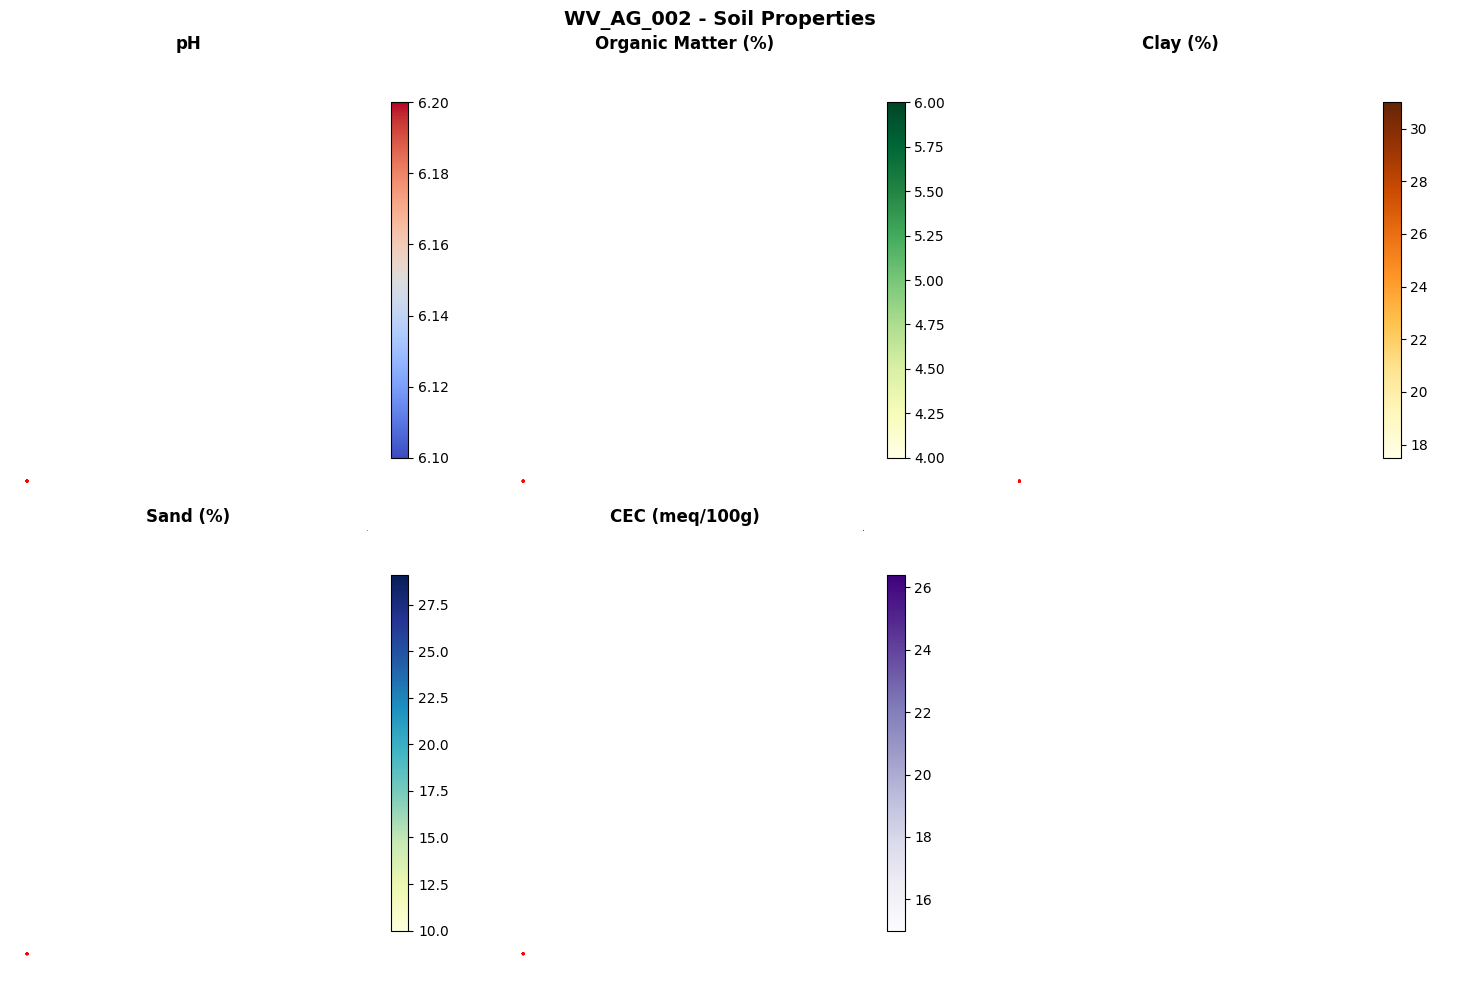

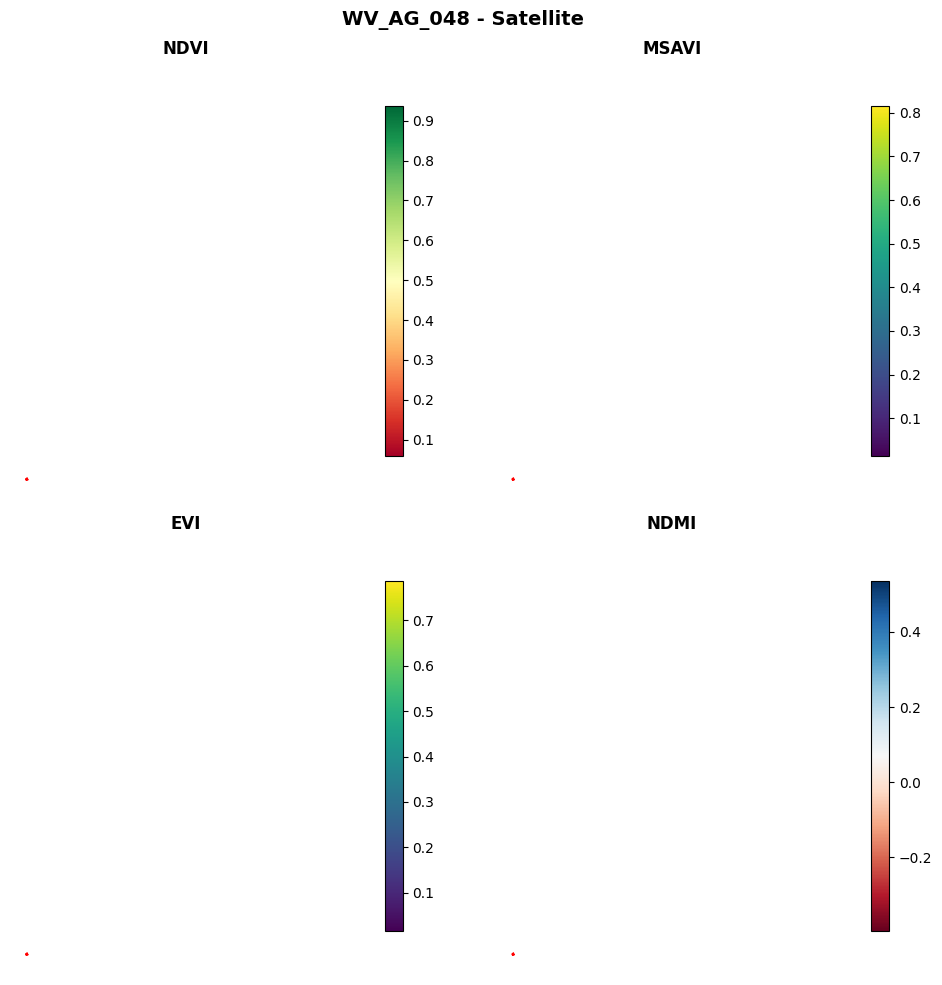

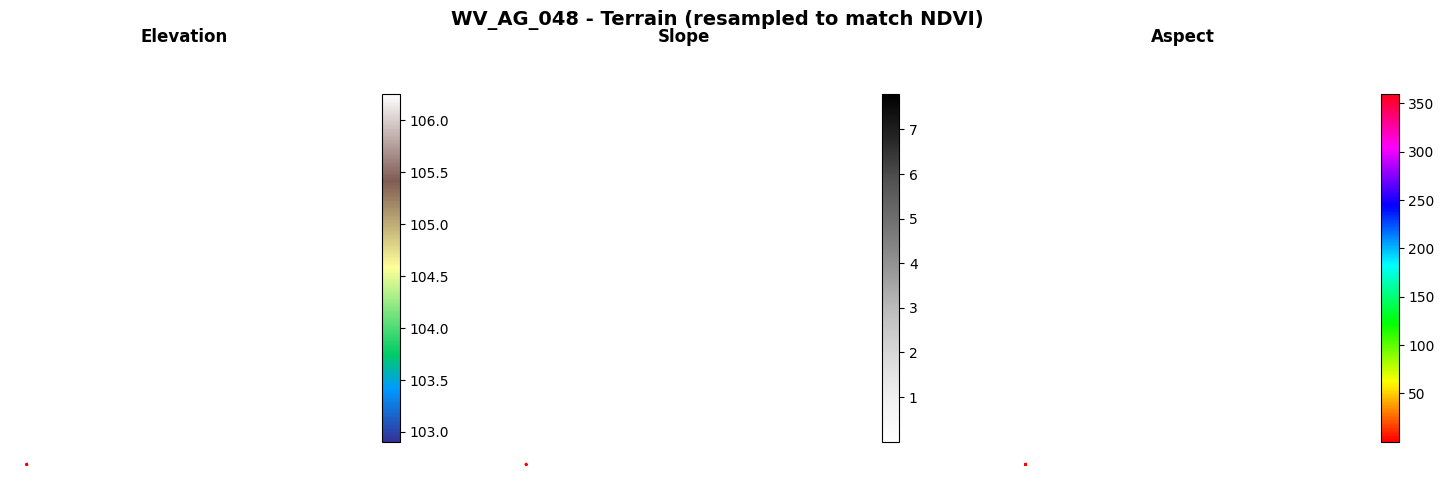

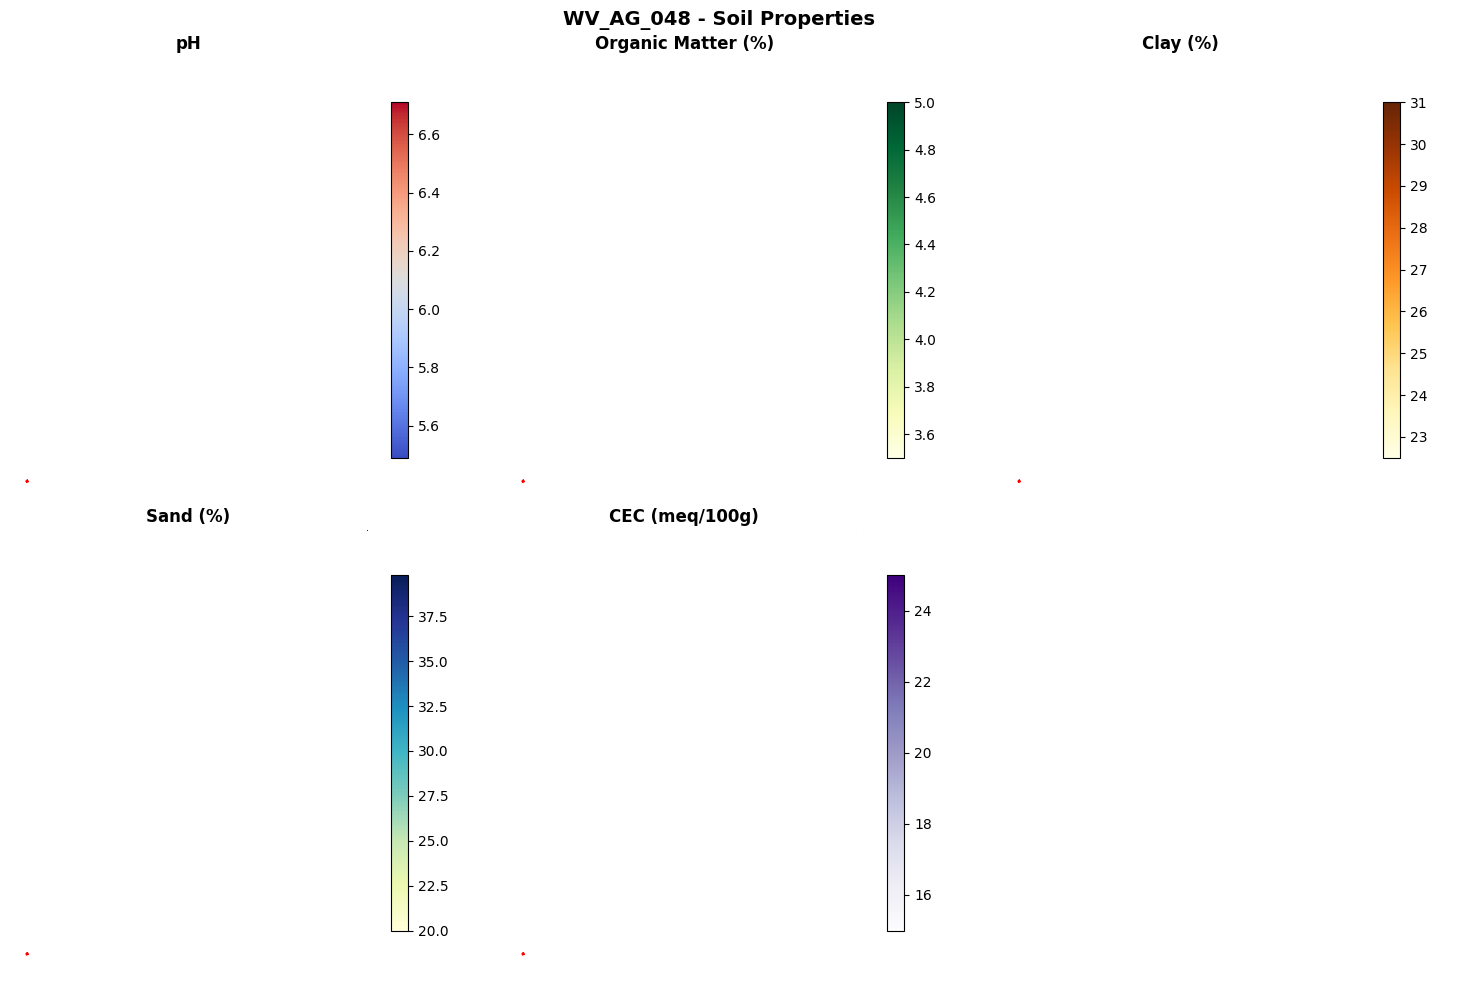

Image maps complete.


In [35]:
# Section 5: Per-Field Image Maps
# Display satellite, terrain, and soil property maps with colorbars

SAT_CMAPS = {'ndvi': 'RdYlGn', 'msavi': 'viridis', 'evi': 'viridis', 'ndmi': 'RdBu'}
TERRAIN_CMAPS = {'elevation': 'terrain', 'slope': 'Greys', 'aspect': 'hsv'}
SOIL_CMAPS = {'ph': 'coolwarm', 'om_pct': 'YlGn', 'clay_pct': 'YlOrBr', 'sand_pct': 'YlGnBu', 'cec': 'Purples'}

for field_id in selected_fields:
    # --- Satellite 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f'{field_id} - Satellite', fontsize=14, fontweight='bold')
    
    for idx, m in enumerate(SATELLITE_METRICS):
        ax = axes[idx//2, idx%2]
        data, _, _ = load_tiff_with_nodata(f'{SATELLITE_DIR}/{field_id}_{m}.tif')
        
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        im = ax.imshow(data, cmap=SAT_CMAPS.get(m,'viridis'), vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        
        ax.set_title(m.upper(), fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # --- Terrain 1x3 ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{field_id} - Terrain', fontsize=14, fontweight='bold')
    
    for idx, p in enumerate(TERRAIN_PROPERTIES):
        ax = axes[idx]
        data, _, _ = load_tiff_with_nodata(f'{TERRAIN_DIR}/{field_id}_{p}.tif')
        
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)
        im = ax.imshow(data, cmap=TERRAIN_CMAPS.get(p,'viridis'), vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.8)
        
        ax.set_title(p.capitalize(), fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # --- Soil 2x3 ---
    soil_tiff_path = f'{SOIL_DIR}/{field_id}_soil.tif'
    soil_labels_path = f'{SOIL_DIR}/{field_id}_soil_labels.json'
    
    if os.path.exists(soil_tiff_path):
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'{field_id} - Soil Properties', fontsize=14, fontweight='bold')
        
        for idx, p in enumerate(SOIL_PROPERTIES):
            ax = axes[idx//3, idx%3]
            data = load_soil_with_properties(soil_tiff_path, soil_labels_path, p)
            
            valid = data[~np.isnan(data)]
            if len(valid) > 0:
                vmin = np.nanpercentile(data, 2)
                vmax = np.nanpercentile(data, 98)
            else:
                vmin, vmax = None, None
            
            im = ax.imshow(data, cmap=SOIL_CMAPS.get(p,'viridis'), vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, shrink=0.8)
            
            ax.set_title(SOIL_PROPERTY_DISPLAY.get(p, p), fontsize=12, fontweight='bold')
            ax.axis('off')
        
        axes[1, 2].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Soil data not available for {field_id}')

print('Image maps complete.')

## Section 6: Per-Field Histograms

Histograms showing distribution of satellite and terrain values for each field.


=== WV_AG_041 Histograms ===


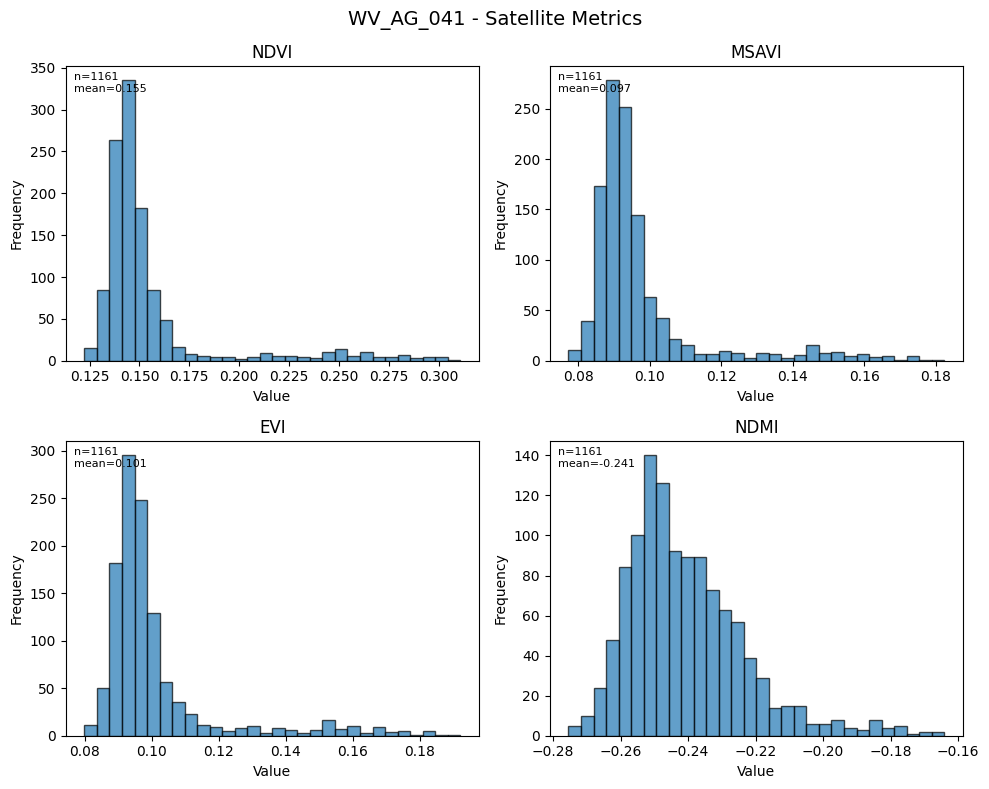

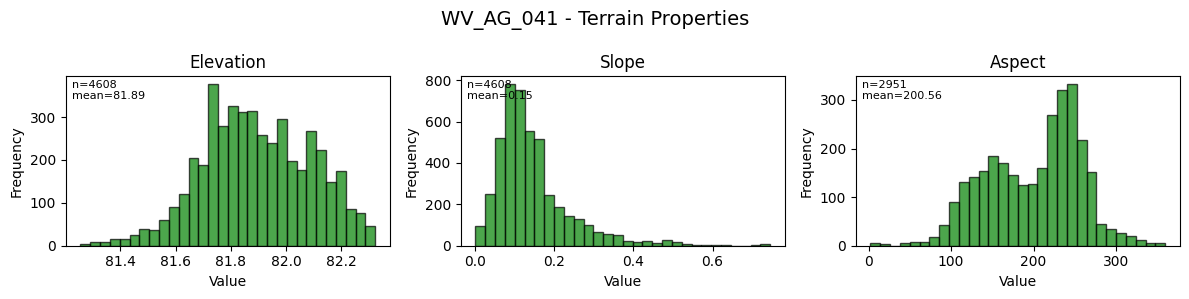


=== WV_AG_008 Histograms ===


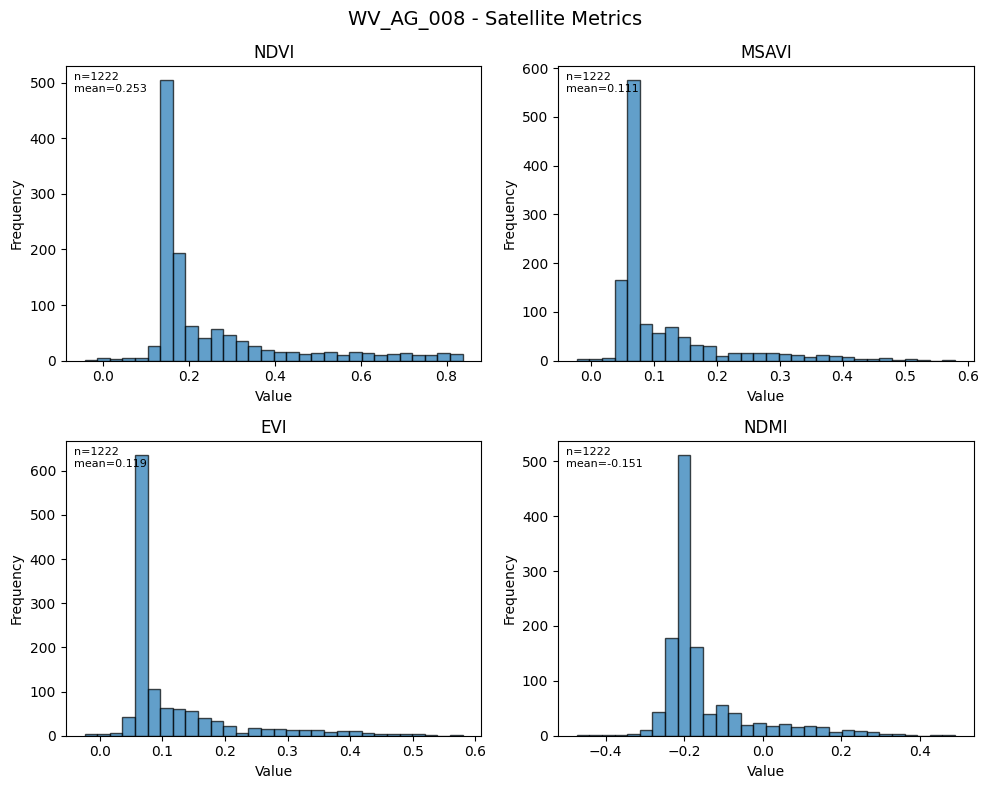

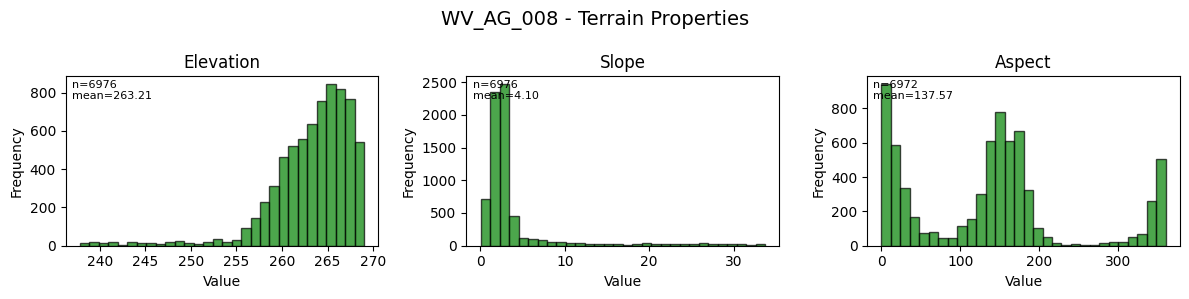


=== WV_AG_002 Histograms ===


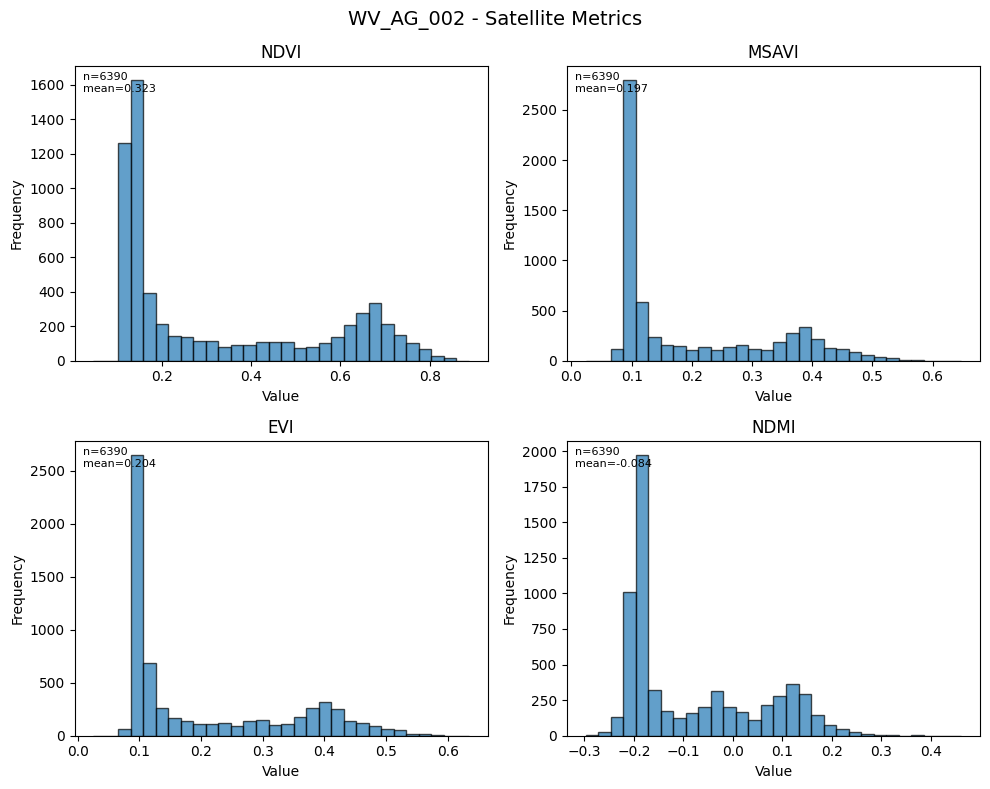

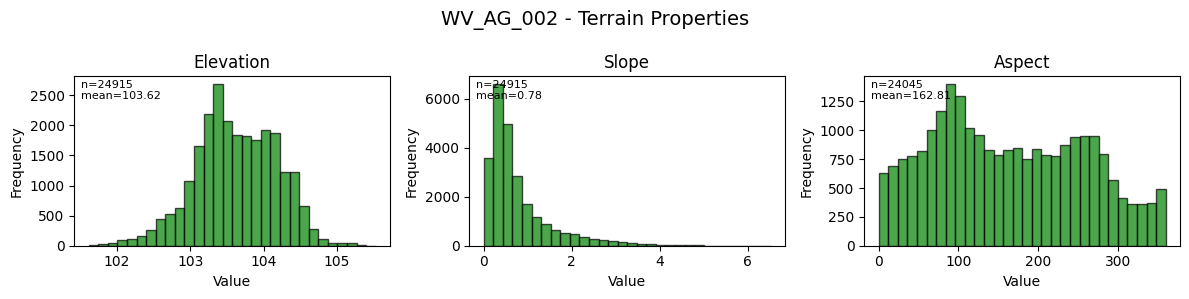


=== WV_AG_048 Histograms ===


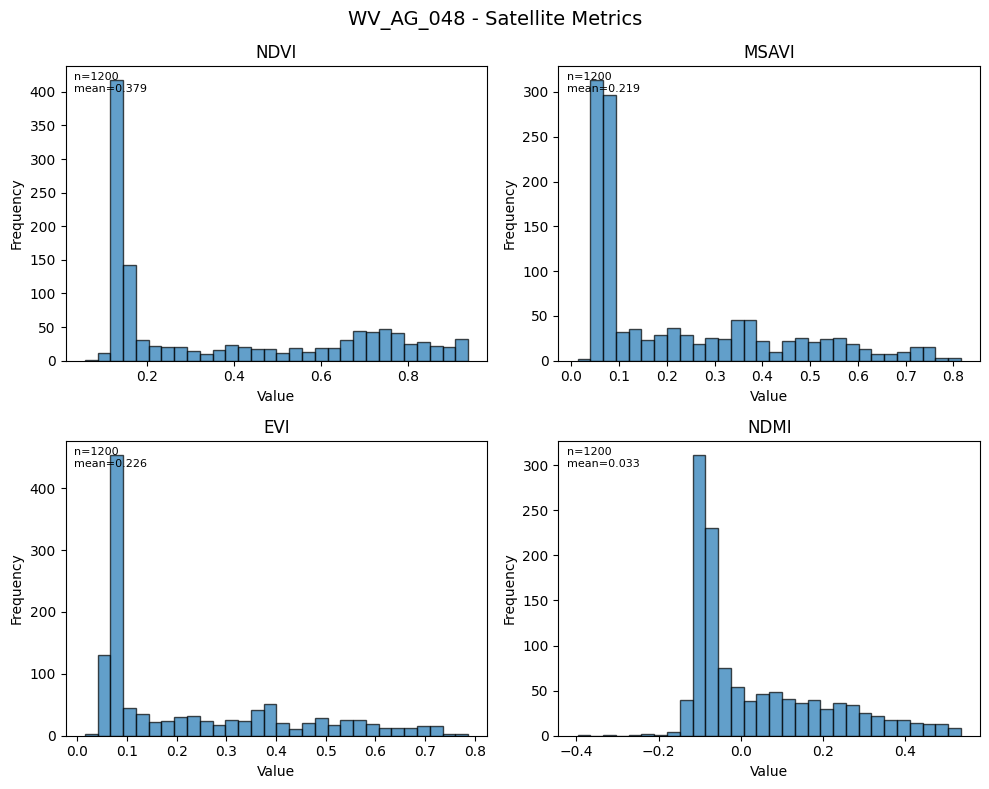

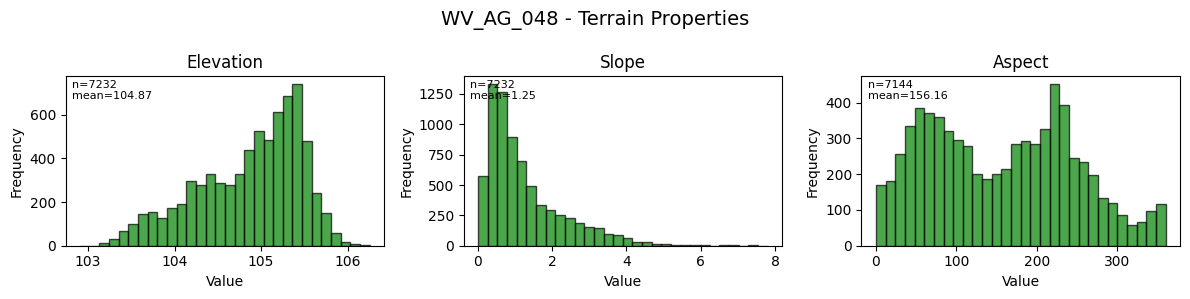

In [36]:
# Generate histograms for each field
for field_id in selected_fields:
    print(f'\n=== {field_id} Histograms ===')
    
    # Satellite histograms
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'{field_id} - Satellite Metrics', fontsize=14)
    
    for idx, metric in enumerate(SATELLITE_METRICS):
        ax = axes[idx // 2, idx % 2]
        sat_path = f'{SATELLITE_DIR}/{field_id}_{metric}.tif'
        if os.path.exists(sat_path):
            data, _, _ = load_tiff_with_nodata(sat_path)
            valid_data = data[~np.isnan(data)]
            ax.hist(valid_data, bins=30, edgecolor='black', alpha=0.7)
            ax.set_title(f'{metric.upper()}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.text(0.02, 0.98, f'n={len(valid_data)}\nmean={np.mean(valid_data):.3f}', 
                    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.tight_layout()
    plt.show()
    
    # Terrain histograms
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle(f'{field_id} - Terrain Properties', fontsize=14)
    
    for idx, prop in enumerate(TERRAIN_PROPERTIES):
        ax = axes[idx]
        terr_path = f'{TERRAIN_DIR}/{field_id}_{prop}.tif'
        if os.path.exists(terr_path):
            data, _, _ = load_tiff_with_nodata(terr_path)
            valid_data = data[~np.isnan(data)]
            ax.hist(valid_data, bins=30, edgecolor='black', alpha=0.7, color='green')
            ax.set_title(f'{prop.capitalize()}')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.text(0.02, 0.98, f'n={len(valid_data)}\nmean={np.mean(valid_data):.2f}', 
                    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.tight_layout()
    plt.show()

## Section 7: Spatial Correlation Analysis

Analyze pixel-by-pixel correlations between satellite metrics and soil/terrain properties.

In [37]:
# Placeholder - will be populated after testing
print('Correlation analysis sections will be added.')

Correlation analysis sections will be added.


## Section 7.0: Interactive Correlation Explorer

Select a field and comparison type to visualize correlations. Shows scatter plot for selected combination and heatmap for all combinations.

In [38]:
# Interactive Correlation Explorer
# Select field, satellite metric, and terrain/soil property to visualize
import ipywidgets as widgets
from IPython.display import display, clear_output

# Dropdown for field selection
field_dropdown = widgets.Dropdown(
    options=selected_fields,
    description='Field:',
    style={'description_width': 'initial'},
    value=selected_fields[0]
)

# Dropdown for satellite metric
sat_dropdown = widgets.Dropdown(
    options=SATELLITE_METRICS,
    description='Satellite:',
    style={'description_width': 'initial'},
    value='ndvi'
)

# Radio button for terrain vs soil
data_type = widgets.RadioButtons(
    options=['Terrain', 'Soil'],
    description='Compare to:',
    style={'description_width': 'initial'},
    value='Soil'
)

# Property dropdown - options will be updated based on data_type
property_dropdown = widgets.Dropdown(
    options=SOIL_PROPERTIES,
    description='Property:',
    style={'description_width': 'initial'},
    value='ph'
)

# Output area for plots
output_area = widgets.Output()

def update_property_options(change):
    if change['new'] == 'Terrain':
        property_dropdown.options = TERRAIN_PROPERTIES
        property_dropdown.value = TERRAIN_PROPERTIES[0]
    else:
        property_dropdown.options = SOIL_PROPERTIES
        property_dropdown.value = SOIL_PROPERTIES[0]

data_type.observe(update_property_options, names='value')

def plot_interactive_correlation(field, sat_metric, data_type_val, prop):
    with output_area:
        clear_output(wait=True)
        
        if data_type_val == 'Terrain':
            # Get terrain data
            terr_data, _, _ = get_or_resample_terrain(field, prop, sat_metric)
            sat_path = f'{SATELLITE_DIR}/{field}_{sat_metric}.tif'
            
            if terr_data is None or not os.path.exists(sat_path):
                print(f'Data not available for {field}')
                return
            
            sat_data, _, _ = load_tiff_with_nodata(sat_path)
            
            # Match shapes
            min_h = min(sat_data.shape[0], terr_data.shape[0])
            min_w = min(sat_data.shape[1], terr_data.shape[1])
            sat_crop = sat_data[:min_h, :min_w].flatten()
            terr_crop = terr_data[:min_h, :min_w].flatten()
            
            x_label = SATELLITE_DISPLAY.get(sat_metric, sat_metric.upper())
            y_label = TERRAIN_DISPLAY.get(prop, prop.capitalize())
            
            r, p, n = calculate_pixel_correlation(sat_crop, terr_crop)
            
            # Scatter plot
            fig = plot_correlation_scatter(sat_crop, terr_crop, x_label, y_label, field, r, p)
            plt.show()
            
            # Heatmap for all terrain properties
            print(f'\n--- Correlation Heatmap: {field} vs Terrain ---')
            heatmap_data = []
            for t_prop in TERRAIN_PROPERTIES:
                t_data, _, _ = get_or_resample_terrain(field, t_prop, sat_metric)
                if t_data is not None:
                    t_crop = t_data[:min_h, :min_w].flatten()
                    rr, pp, _ = calculate_pixel_correlation(sat_crop, t_crop)
                    heatmap_data.append([rr, pp])
            
            if heatmap_data:
                import pandas as pd
                heatmap_df = pd.DataFrame(heatmap_data, 
                                         index=[TERRAIN_DISPLAY.get(p, p) for p in TERRAIN_PROPERTIES],
                                         columns=['r', 'p'])
                
                fig, ax = plt.subplots(figsize=(6, 4))
                sns.heatmap(heatmap_df[['r']], annot=True, fmt='.3f', cmap='RdBu_r', 
                           center=0, vmin=-1, vmax=1, ax=ax)
                ax.set_title(f'{field}: {x_label} vs All Terrain Properties')
                plt.show()
                
        else:
            # Get soil data
            soil_tiff_path = f'{SOIL_DIR}/{field}_soil.tif'
            soil_labels_path = f'{SOIL_DIR}/{field}_soil_labels.json'
            sat_path = f'{SATELLITE_DIR}/{field}_{sat_metric}.tif'
            
            if not os.path.exists(soil_tiff_path):
                print(f'Soil data not available for {field}')
                return
            
            soil_data = load_soil_with_properties(soil_tiff_path, soil_labels_path, prop)
            sat_data, _, _ = load_tiff_with_nodata(sat_path)
            
            # Match shapes
            min_h = min(sat_data.shape[0], soil_data.shape[0])
            min_w = min(sat_data.shape[1], soil_data.shape[1])
            sat_crop = sat_data[:min_h, :min_w].flatten()
            soil_crop = soil_data[:min_h, :min_w].flatten()
            
            x_label = SATELLITE_DISPLAY.get(sat_metric, sat_metric.upper())
            y_label = SOIL_PROPERTY_DISPLAY.get(prop, prop.capitalize())
            
            r, p, n = calculate_pixel_correlation(sat_crop, soil_crop)
            
            # Scatter plot
            fig = plot_correlation_scatter(sat_crop, soil_crop, x_label, y_label, field, r, p)
            plt.show()
            
            # Heatmap for all soil properties
            print(f'\n--- Correlation Heatmap: {field} vs Soil ---')
            heatmap_data = []
            for s_prop in SOIL_PROPERTIES:
                s_data = load_soil_with_properties(soil_tiff_path, soil_labels_path, s_prop)
                s_crop = s_data[:min_h, :min_w].flatten()
                rr, pp, _ = calculate_pixel_correlation(sat_crop, s_crop)
                heatmap_data.append([rr, pp])
            
            import pandas as pd
            heatmap_df = pd.DataFrame(heatmap_data, 
                                     index=[SOIL_PROPERTY_DISPLAY.get(p, p) for p in SOIL_PROPERTIES],
                                     columns=['r', 'p'])
            
            fig, ax = plt.subplots(figsize=(6, 4))
            sns.heatmap(heatmap_df[['r']], annot=True, fmt='.3f', cmap='RdBu_r', 
                       center=0, vmin=-1, vmax=1, ax=ax)
            ax.set_title(f'{field}: {x_label} vs All Soil Properties')
            plt.show()

out = widgets.interactive_output(plot_interactive_correlation, {
    'field': field_dropdown,
    'sat_metric': sat_dropdown,
    'data_type_val': data_type,
    'prop': property_dropdown
})

display(widgets.VBox([
    widgets.HTML('<h3>Select Correlation Parameters</h3>'),
    field_dropdown,
    sat_dropdown,
    data_type,
    property_dropdown,
    output_area
]))
out

Output()

## Section 7.1: Satellite vs Soil Correlations

In [39]:
# Section 7.1: Satellite vs Soil Correlations (Polygon-Based)
# Note: Soil correlations are calculated at the polygon level (mean satellite value per soil polygon)
# This is because SSURGO soil data represents soil map units, not continuous pixel values
# Each pixel within a soil polygon has the same soil property value

results_soil = []

for field_id in selected_fields:
    print(f'Processing {field_id}...')
    
    soil_tiff_path = f'{SOIL_DIR}/{field_id}_soil.tif'
    soil_labels_path = f'{SOIL_DIR}/{field_id}_soil_labels.json'
    
    if not os.path.exists(soil_tiff_path):
        continue
    
    for sat_metric in SATELLITE_METRICS:
        sat_path = f'{SATELLITE_DIR}/{field_id}_{sat_metric}.tif'
        if not os.path.exists(sat_path):
            continue
        
        for soil_prop in SOIL_PROPERTIES:
            # Use polygon-based correlation instead of per-pixel
            r, p, n_polygons = calculate_polygon_correlation(
                soil_tiff_path, sat_path, soil_labels_path, soil_prop
            )
            
            # Also get per-polygon statistics for display
            polygon_stats = get_polygon_stats(soil_tiff_path, sat_path, soil_labels_path, soil_prop)
            
            results_soil.append({
                'field_id': field_id,
                'satellite': sat_metric,
                'soil_property': SOIL_PROPERTY_DISPLAY.get(soil_prop, soil_prop),
                'r': r,
                'p': p,
                'n_polygons': n_polygons,
                'significant': 'Y' if p < 0.05 and not np.isnan(r) else 'N'
            })

df_soil = pd.DataFrame(results_soil)
print('\n=== Satellite vs Soil Correlations (Polygon-Based) ===')
print('Note: Correlations are based on mean satellite values per soil polygon')
print(df_soil.to_string(index=False))

Processing WV_AG_041...
Processing WV_AG_008...
Processing WV_AG_002...
Processing WV_AG_048...

=== Satellite vs Soil Correlations (Polygon-Based) ===
Note: Correlations are based on mean satellite values per soil polygon
 field_id satellite      soil_property   r   p  n_polygons significant
WV_AG_041      ndvi                 pH NaN NaN           1           N
WV_AG_041      ndvi Organic Matter (%) NaN NaN           1           N
WV_AG_041      ndvi           Clay (%) NaN NaN           1           N
WV_AG_041      ndvi           Sand (%) NaN NaN           1           N
WV_AG_041      ndvi     CEC (meq/100g) NaN NaN           1           N
WV_AG_041     msavi                 pH NaN NaN           1           N
WV_AG_041     msavi Organic Matter (%) NaN NaN           1           N
WV_AG_041     msavi           Clay (%) NaN NaN           1           N
WV_AG_041     msavi           Sand (%) NaN NaN           1           N
WV_AG_041     msavi     CEC (meq/100g) NaN NaN           1         

## Section 7.2: Satellite vs Terrain Correlations

In [40]:
# Section 7.2: Satellite vs Terrain Correlations
# Note: Terrain data NoData values (-9999) are now masked in correlation calculations

results_terrain = []

for field_id in selected_fields:
    print(f'Processing {field_id}...')
    
    for sat_metric in SATELLITE_METRICS:
        sat_path = f'{SATELLITE_DIR}/{field_id}_{sat_metric}.tif'
        if not os.path.exists(sat_path):
            continue
        
        # Load satellite data with nodata handling
        sat_data, _, sat_nodata = load_tiff_with_nodata(sat_path)
        
        for terr_prop in TERRAIN_PROPERTIES:
            # Use resampled terrain to match satellite resolution (with nodata handling)
            terr_data, _, terr_nodata = get_or_resample_terrain(field_id, terr_prop, sat_metric)
            
            if terr_data is None:
                print(f'  Warning: No terrain data for {field_id}_{terr_prop}')
                continue
            
            # Match shapes
            min_h = min(sat_data.shape[0], terr_data.shape[0])
            min_w = min(sat_data.shape[1], terr_data.shape[1])
            
            sat_crop = sat_data[:min_h, :min_w]
            terr_crop = terr_data[:min_h, :min_w]
            
            # Use calculate_pixel_correlation which now handles nodata masking
            r, p, n = calculate_pixel_correlation(sat_crop, terr_crop)
            
            results_terrain.append({
                'field_id': field_id,
                'satellite': sat_metric,
                'terrain_property': terr_prop,
                'r': r,
                'p': p,
                'n_pixels': n,
                'significant': 'Y' if p < 0.05 and not np.isnan(r) else 'N'
            })

df_terrain = pd.DataFrame(results_terrain)
print('\n=== Satellite vs Terrain Correlations ===')
print('Note: Terrain NoData values are masked in correlation calculations')
print(df_terrain.to_string(index=False))

Processing WV_AG_041...
Processing WV_AG_008...
Processing WV_AG_002...
Processing WV_AG_048...

=== Satellite vs Terrain Correlations ===
Note: Terrain NoData values are masked in correlation calculations
 field_id satellite terrain_property         r            p  n_pixels significant
WV_AG_041      ndvi        elevation  0.552423 0.000000e+00      1161           Y
WV_AG_041      ndvi            slope  0.276281 8.723411e-22      1161           Y
WV_AG_041      ndvi           aspect  0.067106 6.697158e-02       746           N
WV_AG_041     msavi        elevation  0.591042 0.000000e+00      1161           Y
WV_AG_041     msavi            slope  0.256004 7.886649e-19      1161           Y
WV_AG_041     msavi           aspect  0.066076 7.127944e-02       746           N
WV_AG_041       evi        elevation  0.584561 0.000000e+00      1161           Y
WV_AG_041       evi            slope  0.259743 2.348295e-19      1161           Y
WV_AG_041       evi           aspect  0.066508 6.944779e

## Section 7.3: Key Findings

In [41]:
# Summary of significant correlations
print('=== Summary: Significant Correlations (p < 0.05) ===\n')

# Soil correlations
sig_soil = df_soil[df_soil['significant'] == 'Y']
print(f'Satellite-Soil: {len(sig_soil)} significant correlations')
if len(sig_soil) > 0:
    print(sig_soil.to_string(index=False))

# Terrain correlations
sig_terrain = df_terrain[df_terrain['significant'] == 'Y']
print(f'\nSatellite-Terrain: {len(sig_terrain)} significant correlations')
if len(sig_terrain) > 0:
    print(sig_terrain.to_string(index=False))

# Mean correlations
print('\n=== Mean Correlations Across Fields ===')
print('\nSoil:')
print(df_soil.groupby('soil_property')['r'].mean())
print('\nTerrain:')
print(df_terrain.groupby('terrain_property')['r'].mean())

=== Summary: Significant Correlations (p < 0.05) ===

Satellite-Soil: 0 significant correlations

Satellite-Terrain: 35 significant correlations
 field_id satellite terrain_property         r            p  n_pixels significant
WV_AG_041      ndvi        elevation  0.552423 0.000000e+00      1161           Y
WV_AG_041      ndvi            slope  0.276281 8.723411e-22      1161           Y
WV_AG_041     msavi        elevation  0.591042 0.000000e+00      1161           Y
WV_AG_041     msavi            slope  0.256004 7.886649e-19      1161           Y
WV_AG_041       evi        elevation  0.584561 0.000000e+00      1161           Y
WV_AG_041       evi            slope  0.259743 2.348295e-19      1161           Y
WV_AG_041      ndmi        elevation  0.622914 0.000000e+00      1161           Y
WV_AG_041      ndmi            slope  0.163002 2.330801e-08      1161           Y
WV_AG_008      ndvi        elevation -0.458935 0.000000e+00      1222           Y
WV_AG_008      ndvi            slop